# Facial Keypoint Detection — Paso 1: Preprocesamiento (Local)

Este notebook construye el `frame_index.pkl` que usan `train.ipynb` y `evaluate.ipynb`.

**Estructura esperada:**
```
DL FinalProject/
└── data/
    └── faces_with_keypoints/
        ├── Alison_Lohman_0.npz
        └── ...
```

**Resultado de la ejecución:**
```
DL FinalProject/
└── data/
    ├── faces_with_keypoints/
    └── preprocessed/
        ├── frame_index.pkl
        ├── images_50k.npy
        └── keypoints_50k.npy
```


## 1. Imports

In [1]:
import os
import pickle
import numpy as np
from tqdm import tqdm


## 2. Configuración de rutas

In [ ]:
#Poner el directiorio donde esta la carpeta faces_with_keypoints que es donde estan las imagenes
DATA_DIR = r'F:\\DL_Project\\Data'
NPZ_DIR  = os.path.join(DATA_DIR, 'faces_with_keypoints')
SAVE_DIR = os.path.join(DATA_DIR, 'preprocessed')

os.makedirs(SAVE_DIR, exist_ok=True)

assert os.path.exists(NPZ_DIR), f'No encuentro la carpeta: {NPZ_DIR}'

npz_files = sorted([f for f in os.listdir(NPZ_DIR) if f.endswith('.npz')])
print(f'Carpeta NPZ: {NPZ_DIR}')
print(f'Archivos .npz encontrados: {len(npz_files)}')


Carpeta NPZ: F:\\DL_Project\\Data\faces_with_keypoints
Archivos .npz encontrados: 2194


## 3. Explorar estructura de un NPZ

In [3]:
sample = np.load(os.path.join(NPZ_DIR, npz_files[0]), allow_pickle=True)
print(f'Archivo: {npz_files[0]}')
for key in sample.keys():
    print(f'  "{key}"  →  shape: {sample[key].shape}  dtype: {sample[key].dtype}')


Archivo: AJ_Cook_0.npz
  "colorImages"  →  shape: (192, 125, 3, 73)  dtype: uint8
  "boundingBox"  →  shape: (4, 2, 73)  dtype: float64
  "landmarks2D"  →  shape: (68, 2, 73)  dtype: float64
  "landmarks3D"  →  shape: (68, 3, 73)  dtype: float64


## 4. Visualización de ejemplo de una imagen y su redimension (opcional)

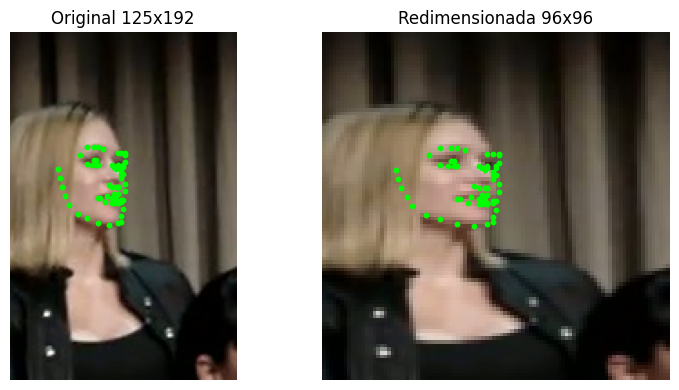

In [4]:
import matplotlib.pyplot as plt
from PIL import Image

IMG_SIZE = 96

data      = np.load(os.path.join(NPZ_DIR, npz_files[0]), allow_pickle=True)
img_raw   = data['colorImages'][:, :, :, 0]
kps_raw   = data['landmarks2D'][:, :, 0]
h, w      = img_raw.shape[0], img_raw.shape[1]

pil_orig  = Image.fromarray(img_raw)
pil_res   = pil_orig.resize((IMG_SIZE, IMG_SIZE), Image.Resampling.BILINEAR)

kps_res      = kps_raw.copy()
kps_res[:,0] = kps_res[:,0] / w * IMG_SIZE
kps_res[:,1] = kps_res[:,1] / h * IMG_SIZE

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(img_raw);         axes[0].scatter(kps_raw[:,0], kps_raw[:,1], s=10, c='lime'); axes[0].set_title(f'Original {w}x{h}');           axes[0].axis('off')
axes[1].imshow(pil_res);         axes[1].scatter(kps_res[:,0], kps_res[:,1], s=10, c='lime'); axes[1].set_title(f'Redimensionada {IMG_SIZE}x{IMG_SIZE}'); axes[1].axis('off')
plt.tight_layout(); plt.show()


## 5. Construir el índice ligero

Recorre todos los NPZs y guarda `(npz_path, frame_idx, kps_norm)` por cada frame válido.
Esto se hace para no carga las imágenes en memoria y asi no tardará tanto en ejecutarse


In [ ]:
IMG_SIZE = 96

index          = []
skipped_files  = 0
skipped_frames = 0

for fname in tqdm(npz_files, desc='Indexando .npz'):
    npz_path = os.path.join(NPZ_DIR, fname)

    try:
        data       = np.load(npz_path, allow_pickle=True)
        images_raw = data['colorImages']
        kps_raw    = data['landmarks2D']
    except Exception as e:
        print(f'Error leyendo {fname}: {e}')
        skipped_files += 1
        continue

    h, w       = images_raw.shape[0], images_raw.shape[1]
    num_frames = images_raw.shape[3]

    for i in range(num_frames):
        kps = kps_raw[:, :, i].astype(np.float32)

        if np.isnan(kps).any():
            skipped_frames += 1
            continue

        kps_norm = kps.copy()
        kps_norm[:, 0] /= w
        kps_norm[:, 1] /= h
        kps_norm = kps_norm.flatten()   # (136,)

        index.append((npz_path, i, kps_norm))

print(f'\nArchivos con error:      {skipped_files}')
print(f'Frames con NaN saltados: {skipped_frames}')
print(f'Frames válidos:          {len(index):,}')
print(f'Memoria del índice:      {len(index) * 136 * 4 / 1e6:.1f} MB')


Indexando .npz:   0%|          | 0/2194 [00:00<?, ?it/s]

Indexando .npz: 100%|██████████| 2194/2194 [02:49<00:00, 12.93it/s]


Archivos con error:      0
Frames con NaN saltados: 0
Frames válidos:          260,399
Memoria del índice:      141.7 MB


## 6. Guardar el índice

In [ ]:
index_path = os.path.join(SAVE_DIR, 'frame_index.pkl')

with open(index_path, 'wb') as f:
    pickle.dump(index, f)

size_mb = os.path.getsize(index_path) / 1e6
print(f'Índice guardado en: {index_path}')
print(f'Tamaño en disco:    {size_mb:.1f} MB')
print(f'Total frames:       {len(index):,}')
print('\n Preprocesamiento completado')


Índice guardado en: F:\\DL_Project\\Data\preprocessed\frame_index.pkl
Tamaño en disco:    152.7 MB
Total frames:       260,399

✅ Preprocesamiento completado. Ya puedes ejecutar train.ipynb.


Guardando 50k frames para no tener cuello de botella al procesar todas las images, tardará un rato pero el train será más rápido

In [ ]:
import numpy as np
from PIL import Image
from tqdm import tqdm

IMG_SIZE = 96

print('Seleccionando 50k frames...')
import random
random.seed(42)
index_small = random.sample(index, 50_000)

images_np    = np.zeros((50_000, 3, IMG_SIZE, IMG_SIZE), dtype=np.float32)
keypoints_np = np.zeros((50_000, 136),                   dtype=np.float32)

for i, (npz_path, frame_idx, kps_norm) in enumerate(tqdm(index_small, desc='Preprocesando')):
    data = np.load(npz_path, allow_pickle=True)
    img  = data['colorImages'][:, :, :, frame_idx]

    pil_img       = Image.fromarray(img)
    pil_img       = pil_img.resize((IMG_SIZE, IMG_SIZE), Image.Resampling.BILINEAR)
    img_tensor    = np.array(pil_img, dtype=np.float32) / 255.0
    images_np[i]  = img_tensor.transpose(2, 0, 1)
    keypoints_np[i] = kps_norm

np.save(os.path.join(SAVE_DIR, 'images_50k.npy'),    images_np)
np.save(os.path.join(SAVE_DIR, 'keypoints_50k.npy'), keypoints_np)

print(f'images_50k.npy:    {images_np.nbytes / 1e9:.2f} GB')
print(f'keypoints_50k.npy: {keypoints_np.nbytes / 1e6:.1f} MB')
print(' Guardado.')

Seleccionando 50k frames...


Preprocesando: 100%|██████████| 50000/50000 [1:16:53<00:00, 10.84it/s]


images_50k.npy:    5.53 GB
keypoints_50k.npy: 27.2 MB
✅ Guardado. Ahora train.ipynb cargará todo en segundos.
